In [1]:
import os
import subprocess
from pathlib import Path

db_path = Path("/home/jovyan/data/raw/wholedatasets/tpch-sf1.db")
wal_path = Path("/home/jovyan/data/raw/wholedatasets/tpch-sf1.db.wal")

print(f"Database exists: {db_path.exists()}")
print(f"WAL file exists: {wal_path.exists()}")

if wal_path.exists():
    print(f"WAL file size: {wal_path.stat().st_size / 1024:.2f} KB")
    
# Check if we can list the directory
print("\nContents of data folder:")
for f in Path("/home/jovyan/data/raw/wholedatasets").iterdir():
    size = f.stat().st_size / (1024**2) if f.is_file() else 0
    print(f"  - {f.name}: {size:.2f} MB")

Database exists: True
WAL file exists: False

Contents of data folder:
  - dataDownloadLink.txt: 0.00 MB
  - tpch-sf1.db: 248.76 MB
  - tpch-sf30.db: 7779.01 MB


In [2]:
import duckdb
import shutil
from pathlib import Path
import time

# Paths
original_db = "/home/jovyan/data/raw/wholedatasets/tpch-sf1.db"
temp_db = f"/tmp/tpch-sf1-copy-{int(time.time())}.db"
output_dir = Path("/home/jovyan/data/raw/tables/original")

# Create output directory
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {output_dir}")

# Copy the database
print("Copying database file...")
shutil.copy2(original_db, temp_db)
print(f"✅ Copied to {temp_db}")

# Connect and export using DuckDB's native parquet writer
try:
    conn = duckdb.connect(temp_db)
    print("✅ Connected to copy")
    
    # Get tables
    tables = conn.execute("SHOW TABLES").fetchall()
    tables = [t[0] for t in tables]
    print(f"Found tables: {tables}")
    
    # Export each table directly to parquet (much faster than pandas)
    for table in tables:
        print(f"\nExporting {table}...")
        
        # Get row count
        count = conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
        
        # Export to parquet
        parquet_file = output_dir / f"{table}.parquet"
        conn.execute(f"""
            COPY (SELECT * FROM {table}) 
            TO '{parquet_file}' 
            (FORMAT PARQUET, COMPRESSION SNAPPY)
        """)
        
        file_size = parquet_file.stat().st_size / (1024 * 1024)
        print(f"  ✅ Saved {count:,} rows, {file_size:.2f} MB")
    
    conn.close()
    print(f"\n✅ All tables exported to {output_dir}")
    
    # Cleanup
    import os
    os.remove(temp_db)
    print("✅ Temporary copy removed")
    
except Exception as e:
    print(f"❌ Error: {e}")

Output directory: /home/jovyan/data/raw/tables/original
Copying database file...
✅ Copied to /tmp/tpch-sf1-copy-1774925037.db
✅ Connected to copy
Found tables: ['customer', 'lineitem', 'nation', 'orders', 'part', 'partsupp', 'region', 'supplier']

Exporting customer...
  ✅ Saved 150,000 rows, 12.06 MB

Exporting lineitem...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ✅ Saved 6,001,215 rows, 262.03 MB

Exporting nation...
  ✅ Saved 25 rows, 0.00 MB

Exporting orders...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ✅ Saved 1,500,000 rows, 58.96 MB

Exporting part...
  ✅ Saved 200,000 rows, 6.62 MB

Exporting partsupp...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  ✅ Saved 800,000 rows, 43.12 MB

Exporting region...
  ✅ Saved 5 rows, 0.00 MB

Exporting supplier...
  ✅ Saved 10,000 rows, 0.77 MB

✅ All tables exported to /home/jovyan/data/raw/tables/original
✅ Temporary copy removed


TPC-H DATABASE VISUALIZATION

📋 Copying database file...
✅ Copied to /tmp/tpch-sf1-copy-1774925084.db

📊 Tables found:
  - customer: 8 columns, 150,000 rows
  - lineitem: 16 columns, 6,001,215 rows
  - nation: 4 columns, 25 rows
  - orders: 9 columns, 1,500,000 rows
  - part: 9 columns, 200,000 rows
  - partsupp: 5 columns, 800,000 rows
  - region: 3 columns, 5 rows
  - supplier: 7 columns, 10,000 rows

📋 TABLE RELATIONSHIPS

📌 CUSTOMER is referenced by:
   • orders.o_custkey → customer.c_custkey

📌 NATION is referenced by:
   • customer.c_nationkey → nation.n_nationkey
   • supplier.s_nationkey → nation.n_nationkey

📌 ORDERS is referenced by:
   • lineitem.l_orderkey → orders.o_orderkey

📌 PART is referenced by:
   • lineitem.l_partkey → part.p_partkey
   • partsupp.ps_partkey → part.p_partkey

📌 REGION is referenced by:
   • nation.n_regionkey → region.r_regionkey

📌 SUPPLIER is referenced by:
   • lineitem.l_suppkey → supplier.s_suppkey
   • partsupp.ps_suppkey → supplier.s_suppkey


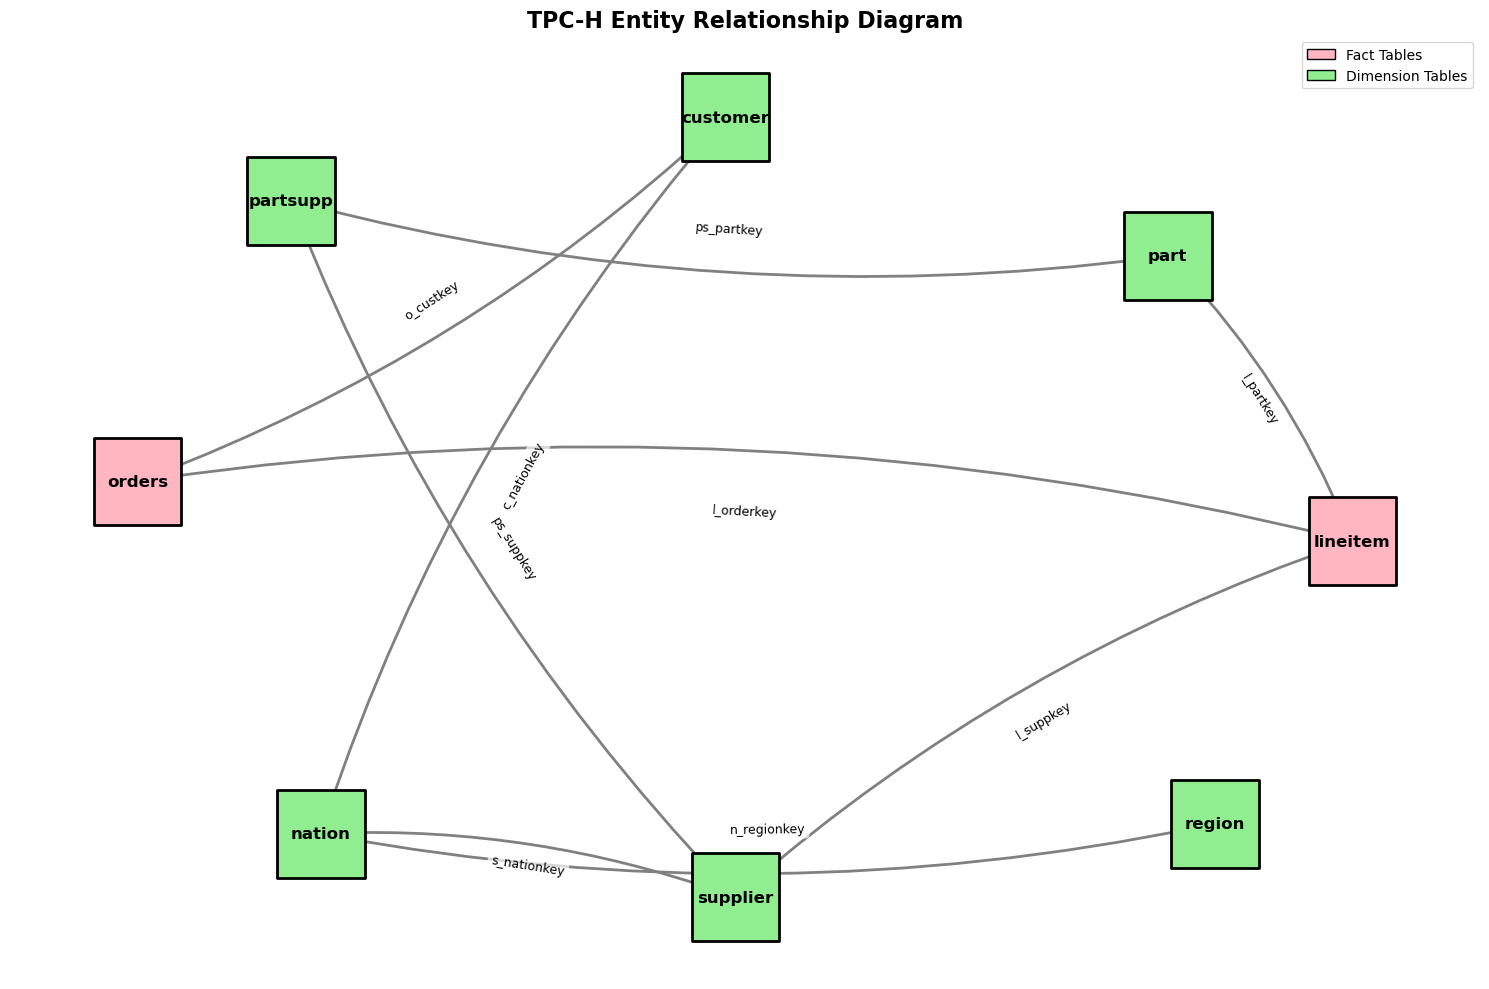


🧹 Temporary copy removed: /tmp/tpch-sf1-copy-1774925084.db

✅ Visualization complete!


In [3]:
import duckdb
import shutil
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
import time
import os

# Use the same working approach - copy the database first
original_db =  "/home/jovyan/data/raw/wholedatasets/tpch-sf1.db"
temp_db = f"/tmp/tpch-sf1-copy-{int(time.time())}.db"
output_dir = Path("/home/jovyan/data/raw/tables/original")

print("="*60)
print("TPC-H DATABASE VISUALIZATION")
print("="*60)

# Copy the database (your working method)
print("\n📋 Copying database file...")
shutil.copy2(original_db, temp_db)
print(f"✅ Copied to {temp_db}")

def get_schema_and_relationships(db_path):
    """Get schema and define relationships from the copied database"""
    
    # Connect to the copied database
    conn = duckdb.connect(db_path, read_only=True)
    
    # Get schema info
    schema_info = {}
    tables = conn.execute("SHOW TABLES").fetchall()
    tables = [t[0] for t in tables]
    
    print("\n📊 Tables found:")
    for table in tables:
        columns = conn.execute(f"PRAGMA table_info({table})").fetchall()
        schema_info[table] = [
            {
                'name': col[1],
                'type': col[2],
                'nullable': not col[3],
                'primary_key': col[5] > 0
            }
            for col in columns
        ]
        # Get row count
        count = conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
        print(f"  - {table}: {len(schema_info[table])} columns, {count:,} rows")
    
    conn.close()
    
    # Define relationships (based on TPC-H schema)
    relationships = [
        # LINEITEM relationships
        {
            'child': 'lineitem',
            'parent': 'orders',
            'child_key': 'l_orderkey',
            'parent_key': 'o_orderkey'
        },
        {
            'child': 'lineitem',
            'parent': 'part',
            'child_key': 'l_partkey',
            'parent_key': 'p_partkey'
        },
        {
            'child': 'lineitem',
            'parent': 'supplier',
            'child_key': 'l_suppkey',
            'parent_key': 's_suppkey'
        },
        
        # ORDERS relationships
        {
            'child': 'orders',
            'parent': 'customer',
            'child_key': 'o_custkey',
            'parent_key': 'c_custkey'
        },
        
        # PARTSUPP relationships
        {
            'child': 'partsupp',
            'parent': 'part',
            'child_key': 'ps_partkey',
            'parent_key': 'p_partkey'
        },
        {
            'child': 'partsupp',
            'parent': 'supplier',
            'child_key': 'ps_suppkey',
            'parent_key': 's_suppkey'
        },
        
        # CUSTOMER relationships
        {
            'child': 'customer',
            'parent': 'nation',
            'child_key': 'c_nationkey',
            'parent_key': 'n_nationkey'
        },
        
        # SUPPLIER relationships
        {
            'child': 'supplier',
            'parent': 'nation',
            'child_key': 's_nationkey',
            'parent_key': 'n_nationkey'
        },
        
        # NATION relationships
        {
            'child': 'nation',
            'parent': 'region',
            'child_key': 'n_regionkey',
            'parent_key': 'r_regionkey'
        }
    ]
    
    return schema_info, relationships

def print_relationship_text(schema_info, relationships):
    """Print relationships in text format"""
    
    print("\n" + "="*60)
    print("📋 TABLE RELATIONSHIPS")
    print("="*60)
    
    # Group by parent
    parent_dict = {}
    for rel in relationships:
        if rel['parent'] not in parent_dict:
            parent_dict[rel['parent']] = []
        parent_dict[rel['parent']].append(rel)
    
    for parent in sorted(parent_dict.keys()):
        if parent in schema_info:
            print(f"\n📌 {parent.upper()} is referenced by:")
            for rel in parent_dict[parent]:
                if rel['child'] in schema_info:  # Only show if child table exists
                    print(f"   • {rel['child']}.{rel['child_key']} → {parent}.{rel['parent_key']}")

def create_er_diagram(schema_info, relationships):
    """Create an ER diagram using networkx"""
    
    print("\n🔨 Creating ER diagram...")
    
    # Create graph
    G = nx.DiGraph()
    
    # Add nodes (tables) that actually exist in the schema
    for table in schema_info.keys():
        G.add_node(table, type='table')
    
    # Add edges (relationships) only if both tables exist
    edge_labels = {}
    for rel in relationships:
        if rel['child'] in schema_info and rel['parent'] in schema_info:
            G.add_edge(rel['child'], rel['parent'])
            edge_labels[(rel['child'], rel['parent'])] = rel['child_key']
    
    if len(G.nodes()) == 0:
        print("❌ No nodes to display")
        return None
    
    # Create plot
    plt.figure(figsize=(15, 10))
    
    # Position nodes
    pos = nx.spring_layout(G, k=3, iterations=50, seed=42)
    
    # Define colors for different types
    fact_tables = ['lineitem', 'orders']
    dimension_tables = ['customer', 'part', 'supplier', 'nation', 'region','partsupp']
    
    node_colors = []
    for node in G.nodes():
        if node in fact_tables:
            node_colors.append('#FFB6C1')  # Light pink for fact tables
        elif node in dimension_tables:
            node_colors.append('#90EE90')  # Light green for dimension tables
        else:
            node_colors.append('lightblue')  # Default
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, 
                          node_color=node_colors, 
                          node_size=4000, 
                          node_shape='s',
                          edgecolors='black',
                          linewidths=2)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, 
                          edge_color='gray', 
                          arrows=True, 
                          arrowsize=25, 
                          arrowstyle='->', 
                          width=2,
                          connectionstyle='arc3,rad=0.1')
    
    # Draw labels
    nx.draw_networkx_labels(G, pos, 
                           font_size=12, 
                           font_weight='bold')
    
    # Draw edge labels
    if edge_labels:
        nx.draw_networkx_edge_labels(G, pos, 
                                    edge_labels, 
                                    font_size=9,
                                    bbox=dict(boxstyle='round,pad=0.3', 
                                             facecolor='white', 
                                             edgecolor='none',
                                             alpha=0.7))
    
    plt.title("TPC-H Entity Relationship Diagram", fontsize=16, fontweight='bold')
    plt.axis('off')
    
    # Add legend
    legend_elements = [
        plt.Rectangle((0,0),1,1, facecolor='#FFB6C1', edgecolor='black', label='Fact Tables'),
        plt.Rectangle((0,0),1,1, facecolor='#90EE90', edgecolor='black', label='Dimension Tables')
    ]
    plt.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return G

def create_simple_relationship_diagram():
    """Create a simple diagram without needing database connection"""
    
    print("\n🔨 Creating simple relationship diagram...")
    
    # Define tables
    tables = ['region', 'nation', 'customer', 'supplier', 'part', 'orders', 'lineitem', 'partsupp']
    
    # Define relationships
    edges = [
        ('lineitem', 'orders'),
        ('lineitem', 'part'),
        ('lineitem', 'supplier'),
        ('orders', 'customer'),
        ('partsupp', 'part'),
        ('partsupp', 'supplier'),
        ('customer', 'nation'),
        ('supplier', 'nation'),
        ('nation', 'region')
    ]
    
    edge_labels = {
        ('lineitem', 'orders'): 'l_orderkey',
        ('lineitem', 'part'): 'l_partkey',
        ('lineitem', 'supplier'): 'l_suppkey',
        ('orders', 'customer'): 'o_custkey',
        ('partsupp', 'part'): 'ps_partkey',
        ('partsupp', 'supplier'): 'ps_suppkey',
        ('customer', 'nation'): 'c_nationkey',
        ('supplier', 'nation'): 's_nationkey',
        ('nation', 'region'): 'n_regionkey'
    }
    
    # Create graph
    G = nx.DiGraph()
    G.add_nodes_from(tables)
    G.add_edges_from(edges)
    
    # Create plot
    plt.figure(figsize=(14, 8))
    
    # Position nodes
    pos = nx.spring_layout(G, k=3, seed=42)
    
    # Define colors
    fact_tables = ['lineitem', 'orders']
    dimension_tables = ['customer', 'part', 'supplier', 'nation', 'region', 'partsupp']
    
    node_colors = []
    for node in G.nodes():
        if node in fact_tables:
            node_colors.append('#FF9999')
        elif node in dimension_tables:
            node_colors.append('#99FF99')
        else:
            node_colors.append('#9999FF')
    
    # Draw
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                          node_size=3500, node_shape='s', 
                          edgecolors='black', linewidths=2)
    nx.draw_networkx_edges(G, pos, edge_color='gray', 
                          arrows=True, arrowsize=20, width=2)
    nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=9)
    
    plt.title("TPC-H Entity Relationship Diagram", fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Print relationship summary
    print("\n" + "="*50)
    print("RELATIONSHIP SUMMARY")
    print("="*50)
    for (child, parent), key in edge_labels.items():
        print(f"{child}.{key} → {parent}")

# Main execution
try:
    # Get schema and relationships from the copied database
    schema, relationships = get_schema_and_relationships(temp_db)
    
    # Print relationships in text
    print_relationship_text(schema, relationships)
    
    # Create ER diagram
    create_er_diagram(schema, relationships)
    
except Exception as e:
    print(f"\n❌ Error accessing database: {e}")
    print("\n🔄 Falling back to simple diagram without database connection...")
    create_simple_relationship_diagram()

finally:
    # Cleanup - remove temporary copy
    try:
        os.remove(temp_db)
        print(f"\n🧹 Temporary copy removed: {temp_db}")
    except:
        pass

print("\n✅ Visualization complete!")